In [1]:
!pip install openpyxl
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

print("Loading data...")
train_df = pd.read_excel("C:/Users/int-winyuyu.m/Downloads/CreditScoring/Creditscore_train_set.xlsx")
test_df = pd.read_excel("C:/Users/int-winyuyu.m/Downloads/CreditScoring/Creditscore_test_set.xlsx")

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Loading data...
Train shape: (73828, 20)
Test shape: (18457, 20)


In [2]:
feature_cols = [
    'Age', 'Occupation', 'Annual_Income', 'Num_Bank_Accounts', 'Num_Credit_Card',
    'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 
    'Payment_Behaviour', 'Monthly_Balance', 'Credit_History_Age_Months'
]

X_train = train_df[feature_cols]
y_train = train_df['Credit_Score']

X_test = test_df[feature_cols]
y_test = test_df['Credit_Score']

print(f"Selected Features: {len(feature_cols)}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

Selected Features: 19
X_train shape: (73828, 19), y_train shape: (73828,)


In [3]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
le = LabelEncoder()

for col in cat_cols:
    # Fit and transform on both train and test to keep them consistent
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

In [4]:
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

# Re-do scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


 Training Logistic Regression...
 Accuracy: 0.74
 ROC-AUC: 0.78

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.90      0.83     13053
           1       0.60      0.38      0.46      5404

    accuracy                           0.74     18457
   macro avg       0.69      0.64      0.65     18457
weighted avg       0.72      0.74      0.72     18457



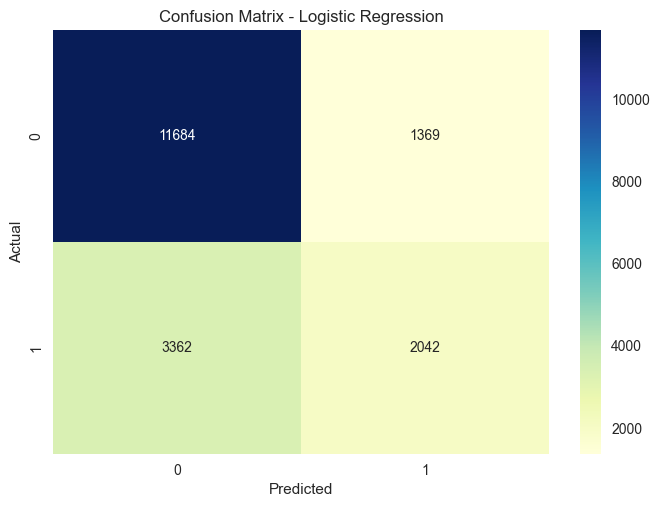


 Training Random Forest...
 Accuracy: 0.87
 ROC-AUC: 0.93

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91     13053
           1       0.79      0.76      0.78      5404

    accuracy                           0.87     18457
   macro avg       0.85      0.84      0.84     18457
weighted avg       0.87      0.87      0.87     18457



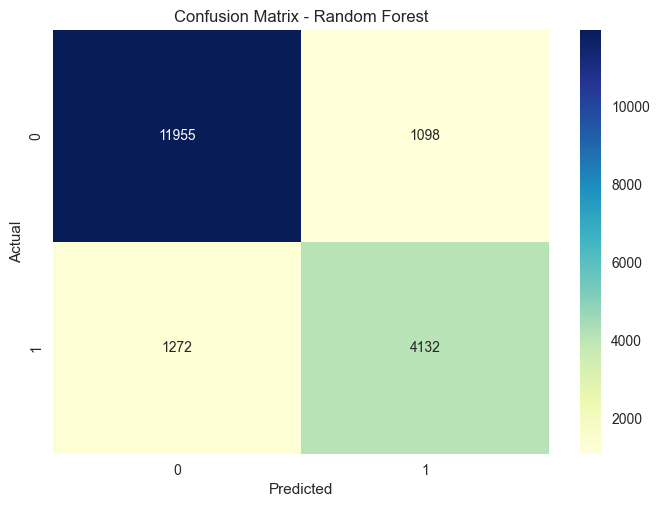


 Training Gradient Boosting...
 Accuracy: 0.82
 ROC-AUC: 0.86

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.87     13053
           1       0.70      0.64      0.67      5404

    accuracy                           0.82     18457
   macro avg       0.78      0.76      0.77     18457
weighted avg       0.81      0.82      0.81     18457



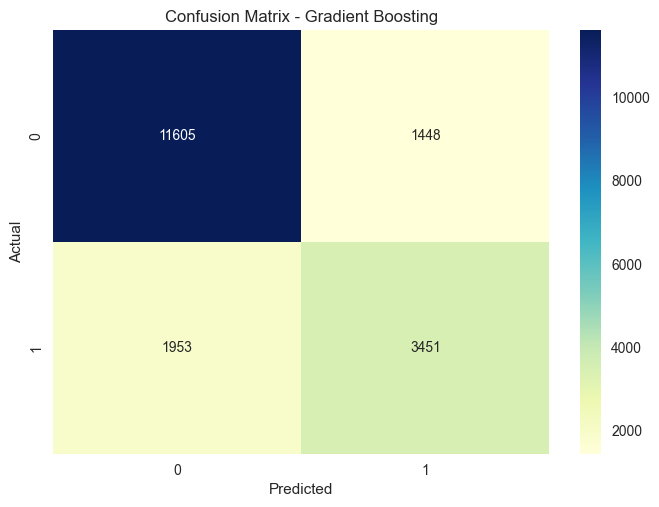


 Training Support Vector Machine...
 Accuracy: 0.79
 ROC-AUC: 0.82

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85     13053
           1       0.65      0.60      0.62      5404

    accuracy                           0.79     18457
   macro avg       0.74      0.73      0.74     18457
weighted avg       0.78      0.79      0.79     18457



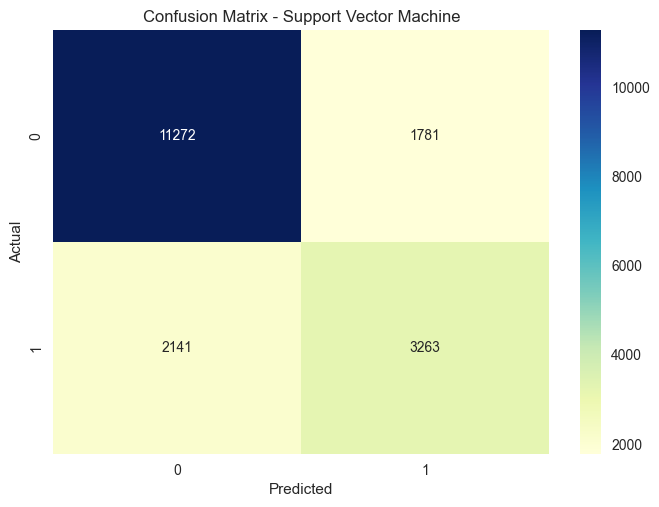


 Training K-Nearest Neighbors...
 Accuracy: 0.77
 ROC-AUC: 0.79

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84     13053
           1       0.63      0.55      0.59      5404

    accuracy                           0.77     18457
   macro avg       0.73      0.71      0.71     18457
weighted avg       0.77      0.77      0.77     18457



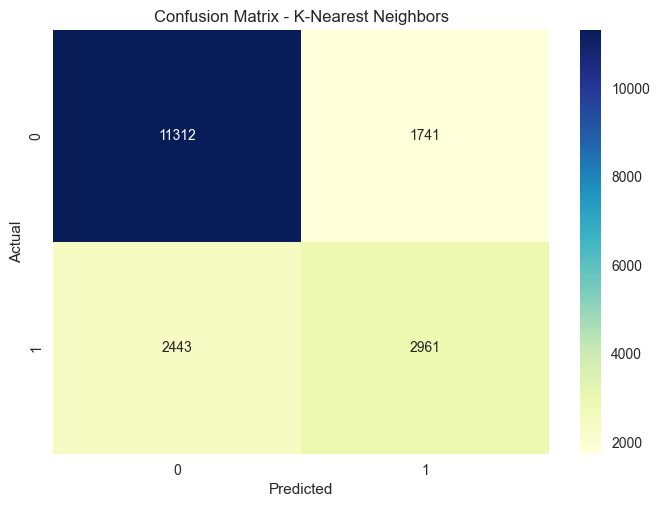


 Training Naive Bayes...
 Accuracy: 0.76
 ROC-AUC: 0.76

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.83     13053
           1       0.60      0.61      0.60      5404

    accuracy                           0.76     18457
   macro avg       0.72      0.72      0.72     18457
weighted avg       0.77      0.76      0.77     18457



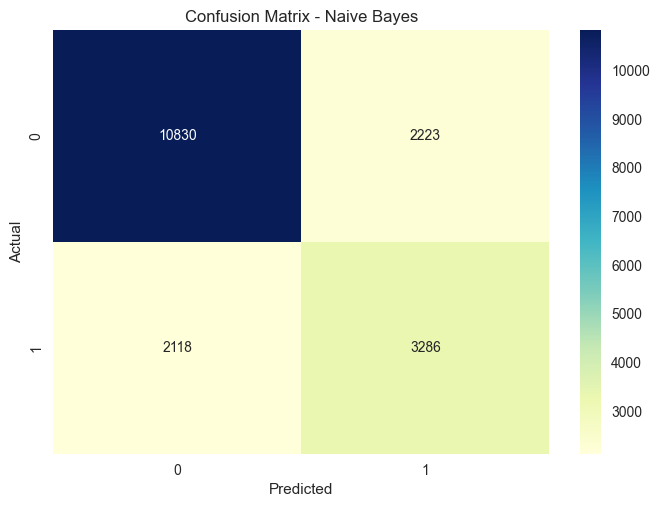


 Training XGBoost...
 Accuracy: 0.85
 ROC-AUC: 0.90

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89     13053
           1       0.75      0.71      0.73      5404

    accuracy                           0.85     18457
   macro avg       0.82      0.81      0.81     18457
weighted avg       0.84      0.85      0.84     18457



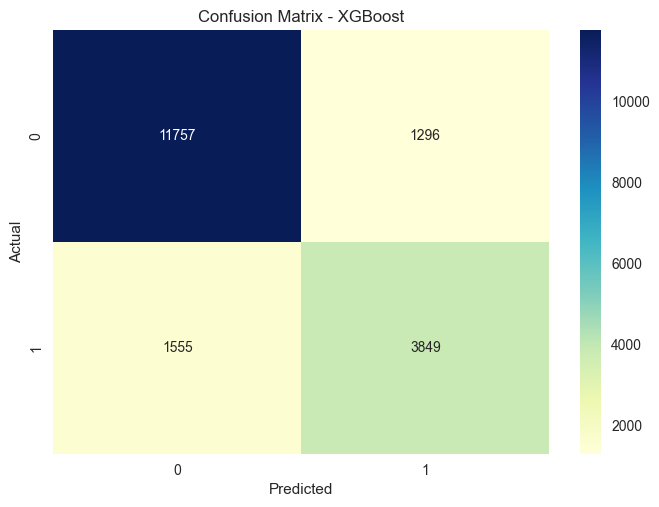

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}
results = {}

for name, model in models.items():
    print(f"\n Training {name}...")

    if name in ["Logistic Regression", "Support Vector Machine", "K-Nearest Neighbors", "Naive Bayes"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    print(f" Accuracy: {acc:.2f}")
    print(f" ROC-AUC: {roc:.2f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Save result inside the loop ✅
    results[name] = {
        "Accuracy": acc,
        "ROC-AUC": roc
    }

    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

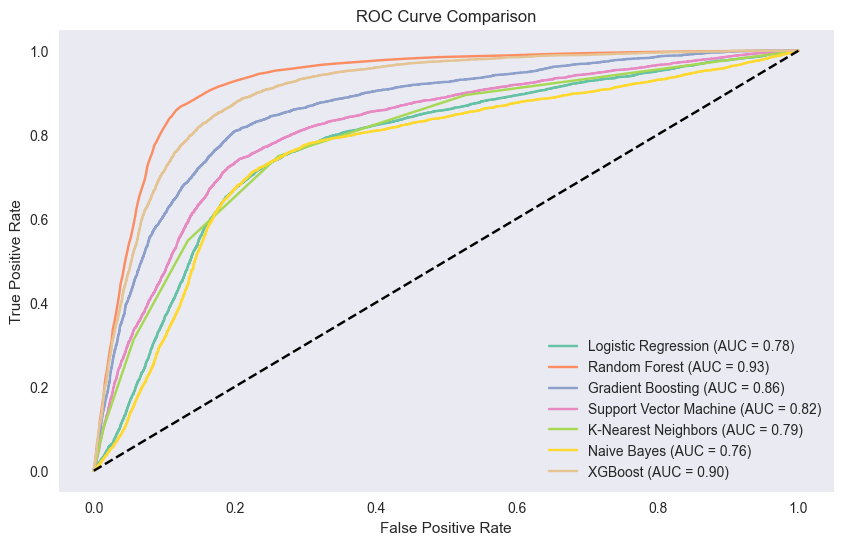

In [6]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))
for name, model in models.items():
    if name in ["Logistic Regression", "Support Vector Machine", "K-Nearest Neighbors", "Naive Bayes"]:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

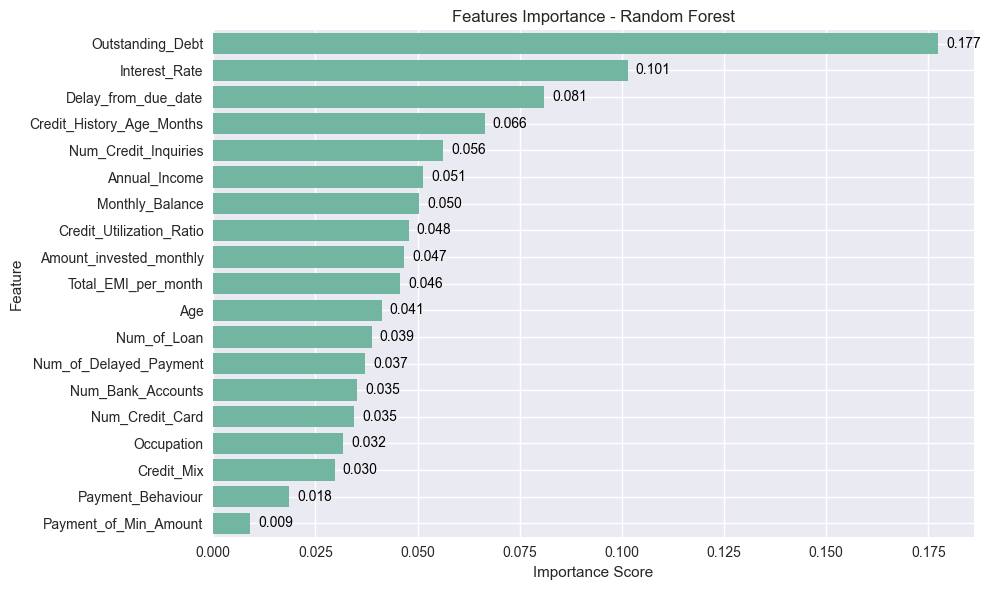

In [7]:
importances = models["Random Forest"].feature_importances_
indices = np.argsort(importances)[::-1]
feat_names = X_train.columns

plt.figure(figsize=(10,6))
ax = sns.barplot(x=importances[indices], y=feat_names[indices])

for i, v in enumerate(importances[indices]):
    ax.text(v + 0.002, i, f'{v:.3f}', color='black', va='center')
    
plt.title("Features Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
import joblib
import zipfile

# Save models
joblib.dump(models['Random Forest'], 'random_forest.pkl')
joblib.dump(models['XGBoost'], 'xgboost.pkl')

# Save preprocessing tools
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')  
# Zip all saved files
with zipfile.ZipFile('model_artifacts.zip', 'w') as zipf:
    zipf.write('random_forest.pkl')
    zipf.write('xgboost.pkl')
    zipf.write('scaler.pkl')
    zipf.write('label_encoder.pkl')

print("✅ All model files zipped!")


✅ All model files zipped!
